# Gdp

In [57]:
from src.worldbank.utils import db
import pandas as pd
import matplotlib as mpl
from typing import Union

# mpl.style.use("dark_background")
# mpl.rcParams = {
#     **mpl.rcParams,
#     "axes.facecolor": "#111",
#     "figure.facecolor": "#151515",
#     # "axes.facecolor": "#1a1a1a",
#     "axes.edgecolor": "gray",
#     "axes.labelcolor": "white",
#     "text.color": "white",
#     "xtick.color": "#666666",
#     "ytick.color": "#666666",
#     "grid.color": "gray",
#     # "figure.facecolor": "#1a1a1a",
#     "figure.edgecolor": "#1a1a1a",
#     # "savefig.facecolor": "#1a1a1a",
#     # "savefig.edgecolor": "#1a1a1a",
# }

### Symbolic select all

It also retrieves the columns

In [96]:
from typing import cast

cols = [c.title() for c in db.select("columns.json", ["gdp"])[0][0].values()]
df = pd.DataFrame(db.select("all"), columns=cols).set_index("Id")
df["Value"] = pd.to_numeric(df["Value"])
df["Year"] = pd.to_datetime(df["Year"], format="%Y")
df.style.format(
    {
        "Year": lambda y: cast(pd.Timestamp, y).strftime("%Y"),
        "Value": "{:.2f}",
    }
)
df

,Country,Year,Value
Id,,,
3577,Africa Eastern and Southern,2023-01-01,1418.363737
3578,Africa Eastern and Southern,2022-01-01,1421.589728
3579,Africa Eastern and Southern,2021-01-01,1408.860838
3580,Africa Eastern and Southern,2020-01-01,1383.377818
3581,Africa Eastern and Southern,2019-01-01,1463.139549
...,...,...,...
7148,Zimbabwe,2014-01-01,1377.254560
7149,Zimbabwe,2013-01-01,1375.851342
7150,Zimbabwe,2012-01-01,1352.135136


In [41]:
pivot = df.pivot(index=["Country"], columns=["Year"])
pivot

Value                            \
Year                          2010-01-01   2011-01-01   2012-01-01   
Country                                                              
Afghanistan                   542.871030   525.426983   568.929021   
Africa Eastern and Southern  1431.324792  1450.051661  1436.173008   
Africa Western and Central   1663.015834  1695.187851  1733.897753   
Albania                      3577.114325  3678.047701  3736.340080   
Algeria                      4456.610274  4501.354301  4518.439790   
...                                  ...          ...          ...   
West Bank and Gaza           2927.081020  3128.108111  3237.916200   
World                        9285.124710  9479.092595  9612.700302   
Yemen, Rep.                  2356.199574  1994.836608  1981.457975   
Zambia                       1183.417124  1208.464246  1258.789386   
Zimbabwe                     1054.397915  1187.318407  1352.135136   

                                                                     \
Year                          2013-01-01   2014-01-01    2015-01-01   
Country                                                               
Afghanistan                   580.603833   575.146246    565.569730   
Africa Eastern and Southern  1457.901496  1475.665545   1479.564123   
Africa Western and Central   1791.113987  1846.050944   1845.767804   
Albania                      3780.699193  3855.760744   3952.803574   
Algeria                      4543.234440  4634.101492   4685.059027   
...                                  ...          ...           ...   
West Bank and Gaza           3309.631202  3227.849345   3272.154324   
World                        9767.040723  9951.540424  10142.143479   
Yemen, Rep.                  2014.728880  1950.162520   1362.173794   
Zambia                       1280.770122  1299.012418   1295.877887   
Zimbabwe                     1375.851342  1377.254560   1386.422847   

                                                                       \
Year                           2016-01-01    2017-01-01    2018-01-01   
Country                                                                 
Afghanistan                    563.872337    562.769574    553.125152   
Africa Eastern and Southern   1472.630604   1472.734783   1471.225033   
Africa Western and Central    1799.974945   1793.465292   1798.339783   
Albania                       4090.372728   4249.820049   4431.555595   
Algeria                       4768.731401   4742.900755   4717.003589   
...                                   ...           ...           ...   
West Bank and Gaza            3483.099035   3462.979861   3417.794408   
World                        10306.944216  10542.823671  10772.308364   
Yemen, Rep.                   1197.958644   1103.456334   1079.329370   
Zambia                        1303.575139   1308.768292   1321.250457   
Zimbabwe                      1379.628343   1415.351332   1464.315294   

                                                                       \
Year                           2019-01-01    2020-01-01    2021-01-01   
Country                                                                 
Afghanistan                    557.861533    527.834554    408.625855   
Africa Eastern and Southern   1463.139549   1383.377818   1408.860838   
Africa Western and Central    1811.727583   1751.195010   1779.340159   
Albania                       4542.268663   4417.041051   4858.052015   
Algeria                       4672.664087   4363.685338   4456.746876   
...                                   ...           ...           ...   
West Bank and Gaza            3378.434621   2922.468011   3051.486070   
World                        10946.228001  10523.921094  11100.293703   
Yemen, Rep.                   1069.786490    951.130341    916.129893   
Zambia                        1301.181330   1228.735001   1269.108218   
Zimbabwe                      1350.309851   1224.272314   1305.220113   

             

In [42]:
# democratic = pivot[pivot.index.str.contains("State", case=False)]
us_arab = pivot.loc[
    [
        "United States",
        "Arab World",
        "Turkiye",
        "European Union",
        "United Arab Emirates",
    ]
]
us_arab = (
    us_arab.transpose()
    .reset_index()
    .drop(columns=["level_0"])
    .set_index("Year")
)
us_arab

Country,United States,Arab World,Turkiye,European Union,United Arab Emirates
Year,,,,,
2010-01-01,52821.404764,5929.230539,8396.923420,29388.299838,42645.635957
2011-01-01,53259.255214,6000.795313,9201.337261,30017.537337,43800.159297
2012-01-01,54080.228650,6152.576169,9519.815089,29745.218195,42868.097503
2013-01-01,54844.242580,6149.325085,10195.847579,29662.122500,43269.840465
2014-01-01,55817.563247,6158.305816,10556.117041,30070.239571,43023.190417
2015-01-01,57040.208214,6203.702636,11049.995110,30716.629570,43534.997268
2016-01-01,57658.670883,6280.662008,11264.614575,31247.895271,43745.288166
2017-01-01,58703.144078,6250.573308,11953.666417,32071.698736,42690.214778
2018-01-01,60127.210276,6301.935834,12148.293128,32672.325899,42679.751908


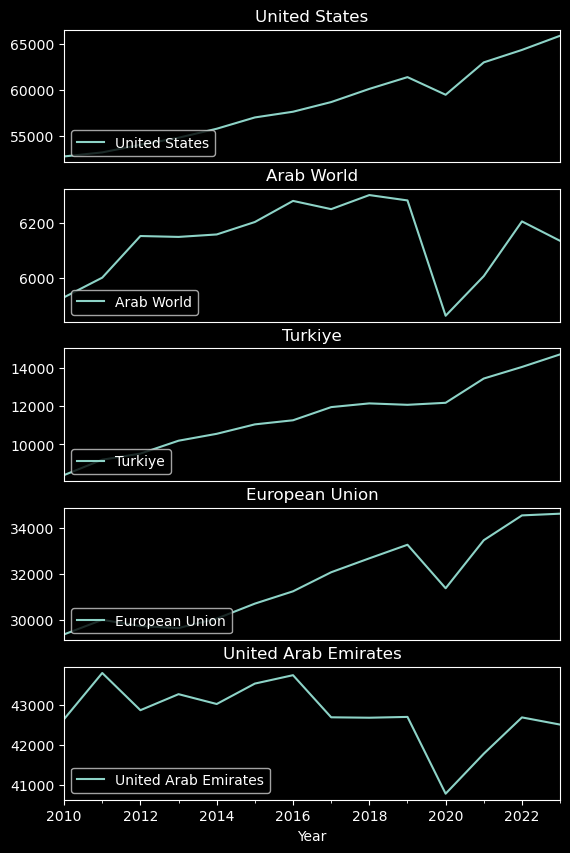

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(len(us_arab.columns), 1)
    fig.figure.set_figheight(10)
    for i, c in enumerate(us_arab.columns):
        us_arab[c].plot(ax=ax[i])
        ax[i].set_title(c)
        ax[i].legend(loc="lower left")
        if i < len(ax) - 1:
            ax[i].get_xaxis().set_visible(False)
    plt.show()

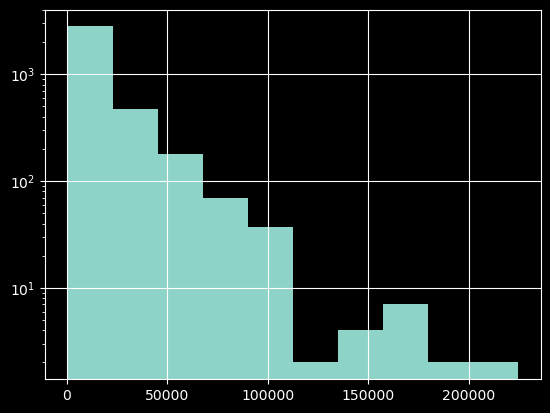

In [44]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots()
    ax.set_yscale("log")
    df["Value"].hist(ax=ax)

In [45]:
pd.DataFrame(df.groupby("Country")["Value"].mean()).sort_values(by="Value")

,Value
Country,
Burundi,274.323584
Central African Republic,416.165309
Somalia,437.047989
Madagascar,446.089776
"Congo, Dem. Rep.",457.951233
...,...
Switzerland,85075.045855
Luxembourg,106644.825075
Bermuda,107588.109216


<Axes: xlabel='Year'>

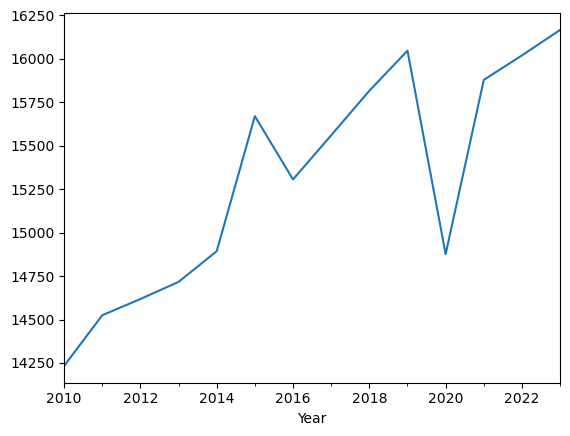

In [46]:
fig, ax = plt.subplots()
df.groupby("Year")["Value"].mean().plot()

In [47]:
d2 = df.copy()
grouped = d2.groupby("Country")["Value"]
d2["Cumulative Average"] = grouped.cumsum() / (grouped.cumcount() + 1)
d2

,Country,Year,Value,Cumulative Average
Id,,,,
3577,Africa Eastern and Southern,2023-01-01,1418.363737,1418.363737
3578,Africa Eastern and Southern,2022-01-01,1421.589728,1419.976732
3579,Africa Eastern and Southern,2021-01-01,1408.860838,1416.271434
3580,Africa Eastern and Southern,2020-01-01,1383.377818,1408.048030
3581,Africa Eastern and Southern,2019-01-01,1463.139549,1419.066334
...,...,...,...,...
7148,Zimbabwe,2014-01-01,1377.254560,1367.542650
7149,Zimbabwe,2013-01-01,1375.851342,1368.297985
7150,Zimbabwe,2012-01-01,1352.135136,1366.951081


### Slope and intercept through sql

In [ ]:
db.exec("view.country.slope-intercept")
cols = ["Country", "Slope", "Intercept"]
line = pd.DataFrame(
    db.select("view.country.slope-intercept"), columns=cols
).set_index("Country")
line

,Slope,Intercept
Country,,
Bangladesh,73.243986,-1.463270e+05
Brunei Darussalam,-394.645509,8.264695e+05
"Iran, Islamic Rep.",24.709175,-4.460575e+04
Luxembourg,230.342452,-3.578407e+05
IDA blend,23.839314,-4.613917e+04
...,...,...
Samoa,-3.522776,1.123330e+04
Equatorial Guinea,-571.879314,1.161304e+06
Antigua and Barbuda,132.061182,-2.497097e+05


In [49]:
# Indices that contain the word `united` regardless of casing
line.loc[line.index.str.contains(r"(?i)^united", regex=True)]

,Slope,Intercept
Country,,
United Arab Emirates,-102.248481,2.489489e+05
United Kingdom,356.155408,-6.732622e+05
United States,972.786406,-1.903162e+06


Slope 972.7864062270728
Intercept -1903162.4162108025


[]

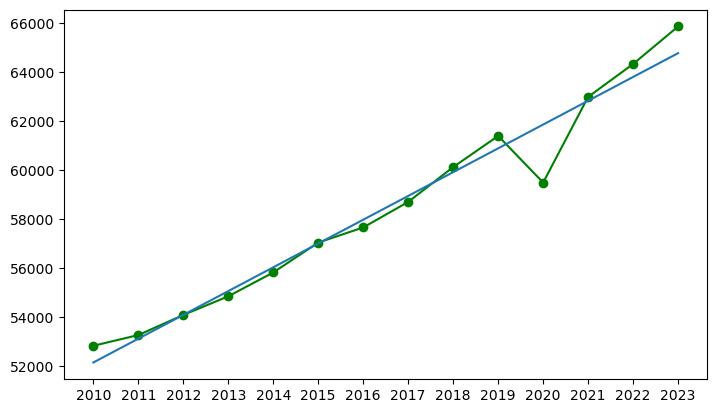

In [132]:
from typing import cast
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
fig.set_figwidth(8.3)
us_gdp = pivot.copy()
us_gdp.columns = us_gdp.columns.droplevel(0)
us_gdp = us_gdp.rename(columns=lambda y: str(y).split("-")[0])

ax.plot(us_gdp.loc[["United States"]].transpose(), marker="o", color="green")

years = np.array(us_gdp.columns.map(lambda v: float(v)), dtype=np.float64)

slope = cast(np.float64, line.loc["United States", "Slope"])
intercept = cast(np.float64, line.loc["United States", "Intercept"])
print("Slope", slope)
print("Intercept", intercept)

ax.plot(years * slope + intercept)

ax.plot()

# Slope and intercept through pandas

In [120]:
g = df.groupby("Country").get_group("United States")
# g.groups.keys()
g["Year"]

Id
7014   2023-01-01
7015   2022-01-01
7016   2021-01-01
7017   2020-01-01
7018   2019-01-01
7019   2018-01-01
7020   2017-01-01
7021   2016-01-01
7022   2015-01-01
7023   2014-01-01
7024   2013-01-01
7025   2012-01-01
7026   2011-01-01
7027   2010-01-01
Name: Year, dtype: datetime64[ns]

# Linear Regression

### Regression through Manual SQL

TODO The method used in this query is inefficient and needs to be worked on

In [ ]:
import pandas as pd
from scipy.stats import linregress

# Assuming your dataframe is named df
# Example structure: df = pd.DataFrame({'country': ['A', 'A', 'B', 'B'], 'year': [2000, 2001, 2000, 2001], 'value': [100, 110, 200, 220]})


# Function to calculate slope and intercept for each country
def get_slope_intercept(group):
    group["year_numeric"] = group["Year"].dt.year - group["Year"].dt.year.min()
    slope, intercept, _, _, _ = linregress(
        group["year_numeric"], group["Value"]
    )
    return pd.Series({"Slope": slope, "Intercept": intercept})


# Group by country and apply the function
result = (
    df.groupby("Country")
    .apply(get_slope_intercept)
    .reset_index()
    .set_index("Country")
)
result.loc["United States"]

/opt/conda/envs/econ/lib/python3.13/site-packages/scipy/stats/_stats_py.py:10730: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/opt/conda/envs/econ/lib/python3.13/site-packages/scipy/stats/_stats_py.py:10744: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/opt/conda/envs/econ/lib/python3.13/site-packages/scipy/stats/_stats_py.py:10750: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)
/opt/conda/envs/econ/lib/python3.13/site-packages/scipy/stats/_stats_py.py:10730: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/opt/conda/envs/econ/lib/python3.13/site-packages/scipy/stats/_stats_py.py:10744: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/opt/conda/envs/econ/lib/python3.13/site-packages/scipy/stats/_stats_py.py:10750: RuntimeWa

Slope          972.786406
Intercept    52138.260306
Name: United States, dtype: float64

In [20]:
db.exec("view.country.min-max-avg")
df = pd.DataFrame(
    db.select("country.min-max-avg"),
    columns=["Country", "Min", "Max", "Avg", "Spread"],
)
df = df.style.format(
    {
        "Min": "{:.2f}",
        "Max": "{:.2f}",
        "Avg": "{:.2f}",
        "Spread": "{:.2f}",
    }
)
df

,Country,Min,Max,Avg,Spread
0,Bangladesh,943.66,1885.38,1369.51,941.71
1,Brunei Darussalam,28549.18,33754.36,30666.79,5205.19
2,"Iran, Islamic Rep.",4916.97,5667.53,5220.30,750.55
3,Luxembourg,104487.74,110425.89,106644.83,5938.14
4,IDA blend,1728.14,2069.11,1932.81,340.97
5,Sweden,48204.66,54878.29,51484.75,6673.63
6,St. Lucia,8379.31,11440.06,10470.32,3060.75
7,Caribbean small states,10893.26,16349.14,12316.17,5455.87
8,Syrian Arab Republic,712.27,1542.72,933.95,830.45
9,Dominican Republic,5698.41,8857.40,7217.10,3158.99


In [80]:
db.exec("view.country.stddev")
df1 = pd.DataFrame(
    db.select("view.country.stddev"),
    columns=[
        "Country",
        "Stddev",
    ],
).set_index("Country")
df1

,Stddev
Country,
"Micronesia, Fed. Sts.",66.762688
Nicaragua,162.271830
IBRD only,831.607571
Qatar,6902.256175
Moldova,498.103318
...,...
Poland,2238.846455
Sri Lanka,465.234488
Norway,2155.351449


### Regression through Postgres methods

In [ ]:
db.exec("view.country.stddev-samp")
df2 = pd.DataFrame(
    db.select("view.country.stddev-samp"), columns=["Country", "StdDevSamp"]
).set_index("Country")
df2

,StdDevSamp
Country,
Bangladesh,307.801107
Brunei Darussalam,1817.944085
"Iran, Islamic Rep.",210.665737
Luxembourg,1805.694487
IDA blend,107.028949
...,...
Samoa,215.175196
Equatorial Guinea,2475.135223
Antigua and Barbuda,1069.452256


In [87]:
df1 = df1.drop_duplicates()
df1

,Stddev
Country,
"Micronesia, Fed. Sts.",66.762688
Nicaragua,162.271830
IBRD only,831.607571
Qatar,6902.256175
Moldova,498.103318
...,...
Liberia,32.949753
Post-demographic dividend,2478.295649
Mexico,324.616127


In [83]:
df2.loc["Samoa"]

StdDevSamp    215.175196
Name: Samoa, dtype: float64

# Slope and Intercept through SQL methods

In [ ]:
df = {}


def view_select(
    df, query, columns=None, index: Union[str, None, list[str]] = None
):
    db.exec(query)
    df[query] = pd.DataFrame(
        db.select(query),
        columns=columns,
    )
    if index is not None:
        df[query] = df[query].set_index(index).sort_index(axis=1)
    return df[query]

In [ ]:
view_select(
    df,
    "view.country.window-slope-intercept",
    ["Country", "Year", "Value", "Slope", "Intercept"],
    ["Country", "Year"],
)

Intercept      Slope        Value
Country     Year                                      
Afghanistan 2010  25709.123794 -12.491152   542.871030
            2011  25709.123794 -12.491152   525.426983
            2012  25709.123794 -12.491152   568.929021
            2013  25709.123794 -12.491152   580.603833
            2014  25709.123794 -12.491152   575.146246
...                        ...        ...          ...
Zimbabwe    2019 -21733.232922  11.438149  1350.309851
            2020 -21733.232922  11.438149  1224.272314
            2021 -21733.232922  11.438149  1305.220113
            2022 -21733.232922  11.438149  1361.914530
            2023 -21733.232922  11.438149  1410.737311

[3576 rows x 3 columns]

In [ ]:
view_select(
    df,
    "view.country.aggregate-slope-intercept",
    ["Country", "Slope", "Intercept"],
    ["Country"],
)

,Intercept,Slope
Country,,
Afghanistan,25709.123794,-12.491152
Africa Eastern and Southern,7369.505637,-2.937568
Africa Western and Central,-11775.450007,6.722763
Albania,-260649.353630,131.374563
Algeria,-2386.756427,3.460026
...,...,...
West Bank and Gaza,22532.742683,-9.587919
World,-327791.768086,167.704111
"Yemen, Rep.",240036.254614,-118.336845


In [ ]:
view_select(
    df,
    "view.country.aggregate-merge-slope-intercept",
    ["Country", "Year", "Value", "Slope", "Intercept"],
    ["Country", "Year"],
)

Intercept      Slope        Value
Country                     Year                                      
Africa Eastern and Southern 2023   7369.505637  -2.937568  1418.363737
                            2022   7369.505637  -2.937568  1421.589728
                            2021   7369.505637  -2.937568  1408.860838
                            2020   7369.505637  -2.937568  1383.377818
                            2019   7369.505637  -2.937568  1463.139549
...                                        ...        ...          ...
Zimbabwe                    2014 -21733.232922  11.438149  1377.254560
                            2013 -21733.232922  11.438149  1375.851342
                            2012 -21733.232922  11.438149  1352.135136
                            2011 -21733.232922  11.438149  1187.318407
                            2010 -21733.232922  11.438149  1054.397915

[3576 rows x 3 columns]

Check if two dataframes are equal

In [88]:
df["view.country.window-slope-intercept"].equals(
    df["view.country.aggregate-merge-slope-intercept"]
)

False

In [ ]:
df1 = df["view.country.window-slope-intercept"].sort_values("Slope")["Slope"]
df2 = df["view.country.aggregate-merge-slope-intercept"].sort_values("Slope")[
    "Slope"
]
df1.equals(df2)
# .equals(
#     df["view.country.aggregate-merge-slope-intercept"]["Slope"].sort()
# )

False

# TODO

You're trying to compare two tables that should produce identical data. Right now their indices differ.

In [110]:
df1 = df["view.country.window-slope-intercept"]
df2 = df["view.country.aggregate-merge-slope-intercept"]

# diff = pd.concat([df1, df2]).drop_duplicates(keep=False).sort_index()
# diff.loc["Afghanistan"]
df1.sort_index().sort_values(by=df1.columns.tolist()).reset_index()
df2.sort_index().sort_values(by=df2.columns.tolist()).reset_index()

all(df1.columns == df2.columns)
all(df1.index == df2.index)
# df1.index
# df2.index
df1.index

MultiIndex([('Afghanistan', 2010),
            ('Afghanistan', 2011),
            ('Afghanistan', 2012),
            ('Afghanistan', 2013),
            ('Afghanistan', 2014),
            ('Afghanistan', 2015),
            ('Afghanistan', 2016),
            ('Afghanistan', 2017),
            ('Afghanistan', 2018),
            ('Afghanistan', 2019),
            ...
            (   'Zimbabwe', 2014),
            (   'Zimbabwe', 2015),
            (   'Zimbabwe', 2016),
            (   'Zimbabwe', 2017),
            (   'Zimbabwe', 2018),
            (   'Zimbabwe', 2019),
            (   'Zimbabwe', 2020),
            (   'Zimbabwe', 2021),
            (   'Zimbabwe', 2022),
            (   'Zimbabwe', 2023)],
           names=['Country', 'Year'], length=3576)